In [1]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2024_Phase_Camera_FM_Design/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

from scipy.signal import correlate2d, convolve2d
from scipy.interpolate import RegularGridInterpolator

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


# Trying to match speckle sizes from experiment with simulation

**Moving completely to thin lens modeling**

* Parameters to optimize:
    * Cube lateral size and height
    * Mask distance to image plane

* ~~Ensuring proper sampling, wavefield size, and boundary conditions~~
* *Simulate and save phase mask with proper sizes*
    * *Try different densities of structures*
    * ~~Compare outputs from different samplings~~
* Ensure proper simulation w.r.t. medium RIs
* C~~ompare BPM vs Thin sample modeling~~
    * ~~Make videos for propagation distances~~
* Problem specification: FOV and same sampling, but spatial resolution/ spatial frequency limited by distance and speckle size?
    * ~~Speckle size increases with distance?~~
* Averaging opoerator with stride to map output onto sensor pixels
* Finding minimum sampling frequency: Confirm when sampling frequency starts to effect output

Text(0, 0.5, 'Normalized Intensity')

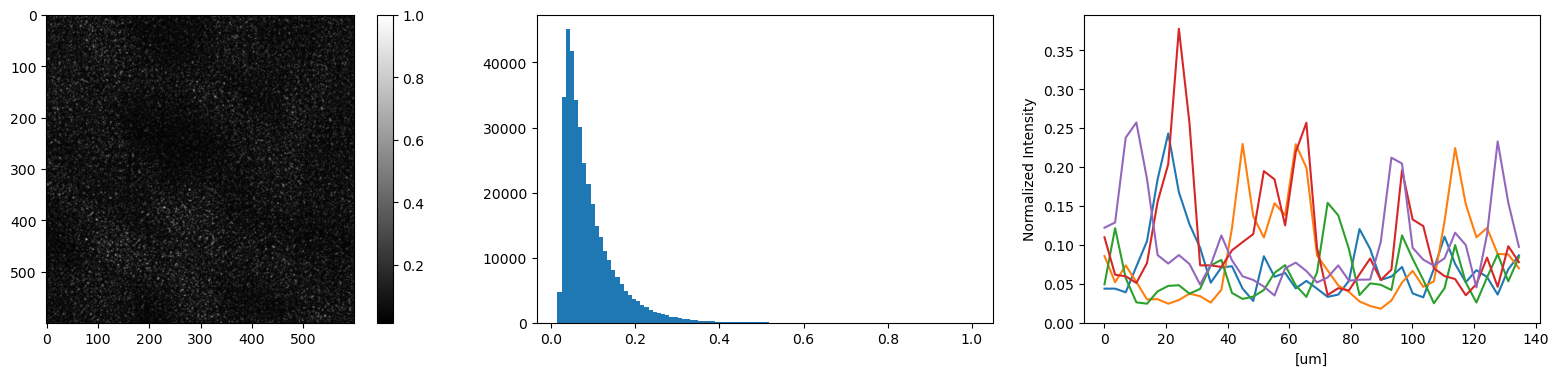

In [2]:
# load exp speckle pattern

speck_path = '/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/Data/cselabslm/2025_CWS_v3/2025_05_13/SiO2_w_oil_ref_2.tiff'
ref_img = tifffile.imread(speck_path)[200:800, 200:800]
ref_img = ref_img/ref_img.max()

fig, axs = plt.subplots(1, 3, figsize=(20, 4))

cm0 = axs[0].imshow(ref_img, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

axs[1].hist(ref_img.reshape(-1), bins=100);

axs[2].plot(np.arange(40)*3.45, ref_img[100, 200:240])
axs[2].plot(np.arange(40)*3.45, ref_img[200, 200:240])
axs[2].plot(np.arange(40)*3.45, ref_img[300, 200:240])
axs[2].plot(np.arange(40)*3.45, ref_img[400, 200:240])
axs[2].plot(np.arange(40)*3.45, ref_img[500, 200:240])

axs[2].set_xlabel('[um]')
axs[2].set_ylabel('Normalized Intensity')

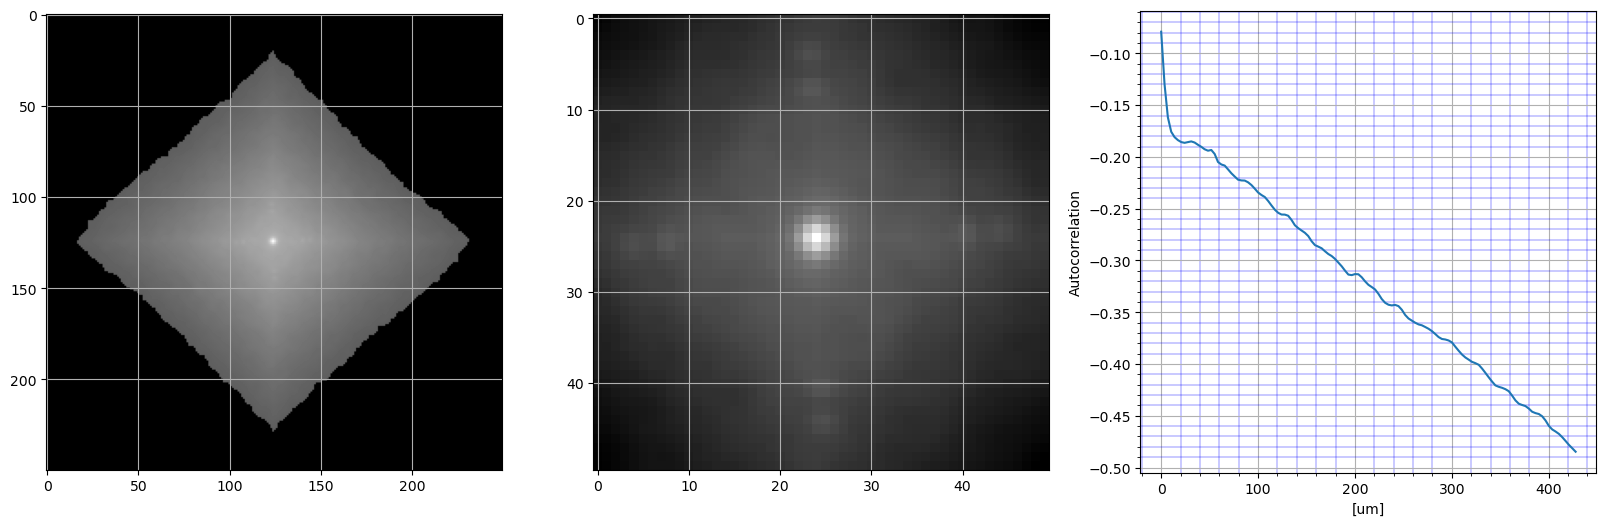

In [3]:
corr_ref_img = correlate2d(ref_img[100:350, 100:350], ref_img[100:350, 100:350], mode='same')
corr_ref_img = corr_ref_img/corr_ref_img.max()

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

cm1 = axs[0].imshow(np.where(corr_ref_img > np.exp(-1), corr_ref_img, 0)[:, :], cmap='gray')
axs[0].grid()

cm1 = axs[1].imshow(np.log10(np.where(corr_ref_img > np.exp(-1), corr_ref_img, 0)[100:150, 100:150]), cmap='gray')
axs[1].grid()

axs[2].plot(np.arange(125)*3.45, np.log10(corr_ref_img[125, 125:]))

axs[2].set_xlabel('[um]')
axs[2].set_ylabel('Autocorrelation')

axs[2].minorticks_on()
axs[2].grid(visible=True, which='minor', color='b', linewidth=0.3)
axs[2].grid(visible=True, which='major')

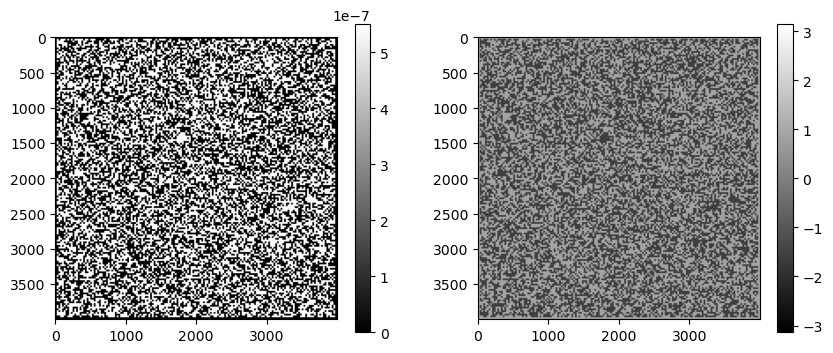

In [4]:
# create phase mask:

# Grid and propagation parameters setup
wl = 640e-9
n_0 = 1.

dx = 500e-9 # dx == dy
nx = 4000 # nx == ny
side_length = 12.9e-6
height = 550e-9

tile_size = int(side_length/dx)

h_map = geometry.initialize_hmap_uniform_sampling([nx, nx], tile_size, height, prob=0.5)

t = h_map.max()
RI = 1.46

# field = np.zeros([nx, nx])
# field[:, :] = 10

phase_delay = np.exp(-1j*(2*np.pi/wl)*(h_map*RI + (t-h_map)*n_0))

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

cm0 = axs[0].imshow(h_map, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(phase_delay), cmap='gray', vmin=-3.14, vmax=3.14)
plt.colorbar(cm1, ax=axs[1])

plt.show()

Text(0, 0.5, 'Normalized Intensity')

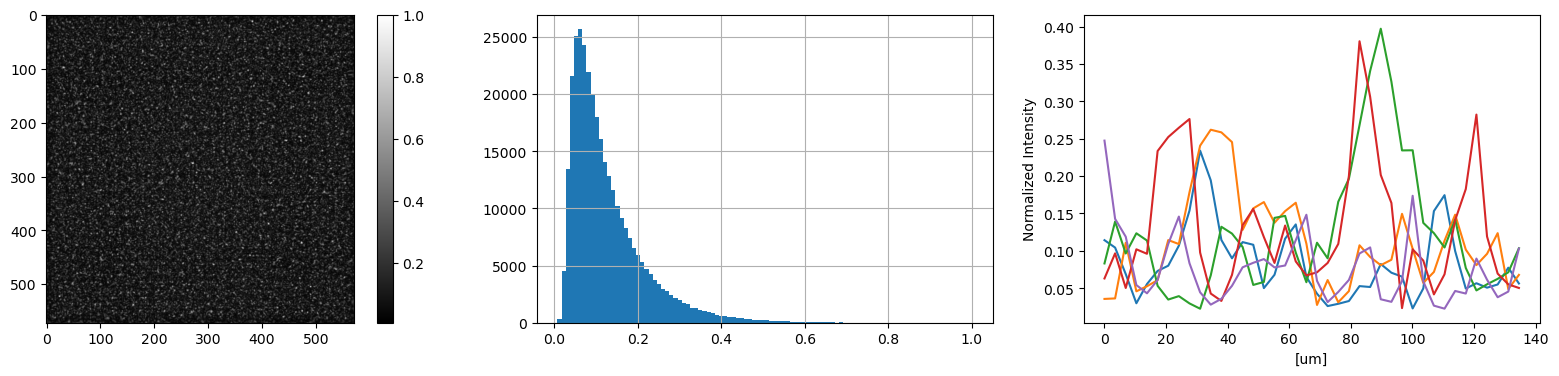

In [25]:
# x_cords = np.arange(-nx/2, nx/2)*dx
# X, Y = np.meshgrid(x_cords, x_cords, indexing='ij')

output_field_intensity_spat = 0
# -1e-3 -> 1e3
# df = (3e8/534.99999e-9 - 3e8/535.00001e-9)/5
for angle in [0]:
    output_field_intensity = 0
    # tilt_wave = np.exp(1j*2*np.pi/wl * (np.sin(angle)*X))
    for wl in np.linspace(533e-9, 537e-9, 13):
        phase_delay = np.exp(-1j*(2*np.pi/wl)*(h_map*RI + (t-h_map)*n_0))
        output_field = propagator.propagate(np.pad(phase_delay, 256, 'edge'), wl/1.49, [dx, dx], 1e-3, padding=None)
        output_field_intensity += propagator.propagate(output_field, wl, [dx, dx], 1e-3, padding=None)
    output_field_intensity_spat += np.abs(output_field_intensity)**2

# digit on the sensor
conv_opt_dx = int(3.5e-6/dx)
conv_opt = np.ones([conv_opt_dx, conv_opt_dx])
output_field_intensity_spat = convolve2d(output_field_intensity_spat[256:-256, 256:-256], conv_opt, mode='same')[::conv_opt_dx, ::conv_opt_dx]  # cropping out the background
# output_field_intensity_spat += np.random.normal(scale=10, size=output_field_intensity_spat.shape)

output_field_intensity_spat = output_field_intensity_spat/output_field_intensity_spat.max()

fig, axs = plt.subplots(1, 3, figsize=(20, 4))

cm0 = axs[0].imshow(output_field_intensity_spat, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

axs[1].hist(output_field_intensity_spat.reshape(-1), bins=100);
axs[1].grid()

axs[2].plot(np.arange(40)*3.45, output_field_intensity_spat[100, 200:240])
axs[2].plot(np.arange(40)*3.45, output_field_intensity_spat[200, 200:240])
axs[2].plot(np.arange(40)*3.45, output_field_intensity_spat[300, 200:240])
axs[2].plot(np.arange(40)*3.45, output_field_intensity_spat[400, 200:240])
axs[2].plot(np.arange(40)*3.45, output_field_intensity_spat[500, 200:240])

axs[2].set_xlabel('[um]')
axs[2].set_ylabel('Normalized Intensity')

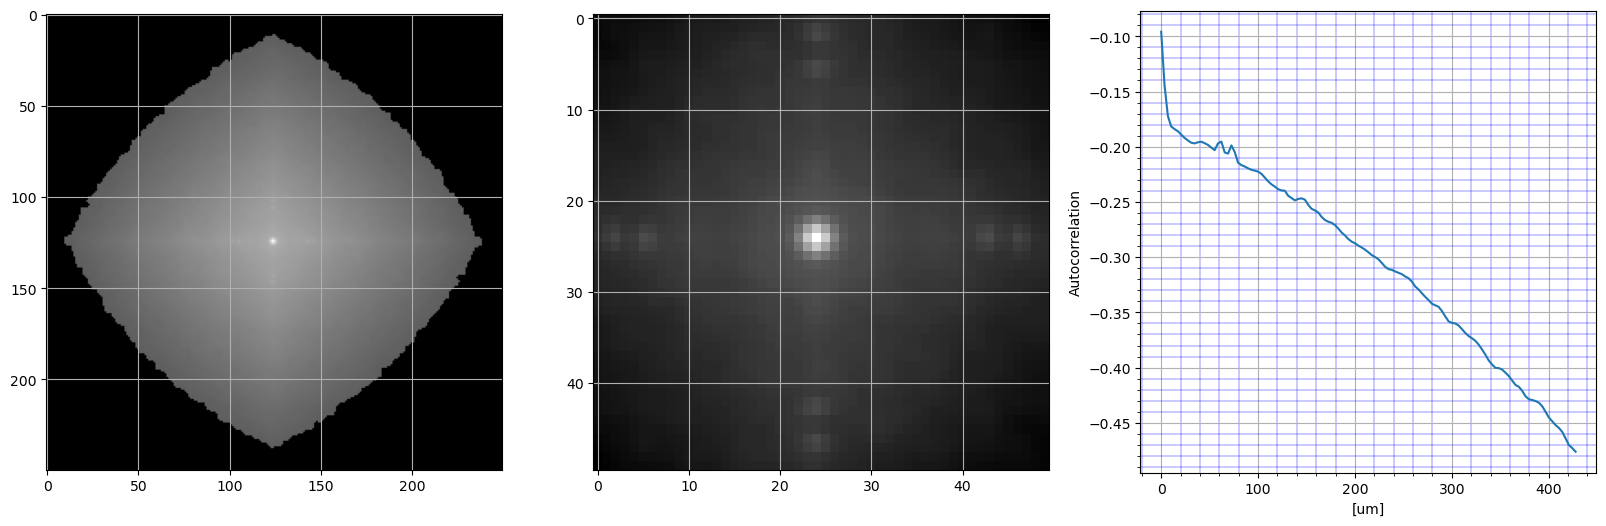

In [26]:
corr_sim_img = correlate2d(output_field_intensity_spat[200:450, 200:450], output_field_intensity_spat[200:450, 200:450], mode='same')
corr_sim_img = corr_sim_img/corr_sim_img.max()

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

cm1 = axs[0].imshow(np.where(corr_sim_img > np.exp(-1), corr_sim_img, 0)[:, :], cmap='gray')
axs[0].grid()

cm1 = axs[1].imshow(np.log10(np.where(corr_sim_img > np.exp(-1), corr_sim_img, 0)[100:150, 100:150]), cmap='gray')
axs[1].grid()

axs[2].plot(np.arange(125)*3.45, np.log10(corr_sim_img[125, 125:]))

axs[2].set_xlabel('[um]')
axs[2].set_ylabel('Autocorrelation')

axs[2].minorticks_on()
axs[2].grid(visible=True, which='minor', color='b', linewidth=0.3)
axs[2].grid(visible=True, which='major')

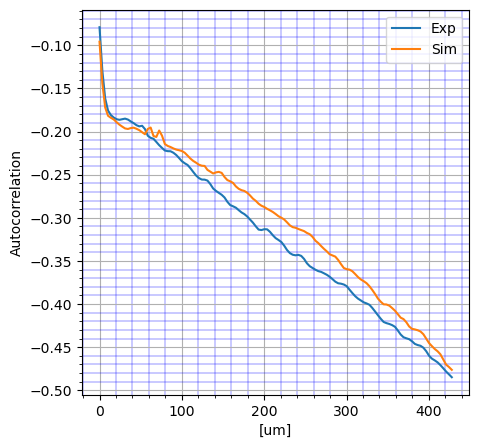

In [27]:
fig, axs = plt.subplots(1, figsize=(5, 5))

axs.plot(np.arange(125)*3.45, np.log10(corr_ref_img[125, 125:]), label='Exp')
axs.plot(np.arange(125)*3.45, np.log10(corr_sim_img[125, 125:]), label='Sim')

axs.set_xlabel('[um]')
axs.set_ylabel('Autocorrelation')

axs.minorticks_on()
axs.grid(visible=True, which='minor', color='b', linewidth=0.3)
axs.grid(visible=True, which='major')

plt.legend()

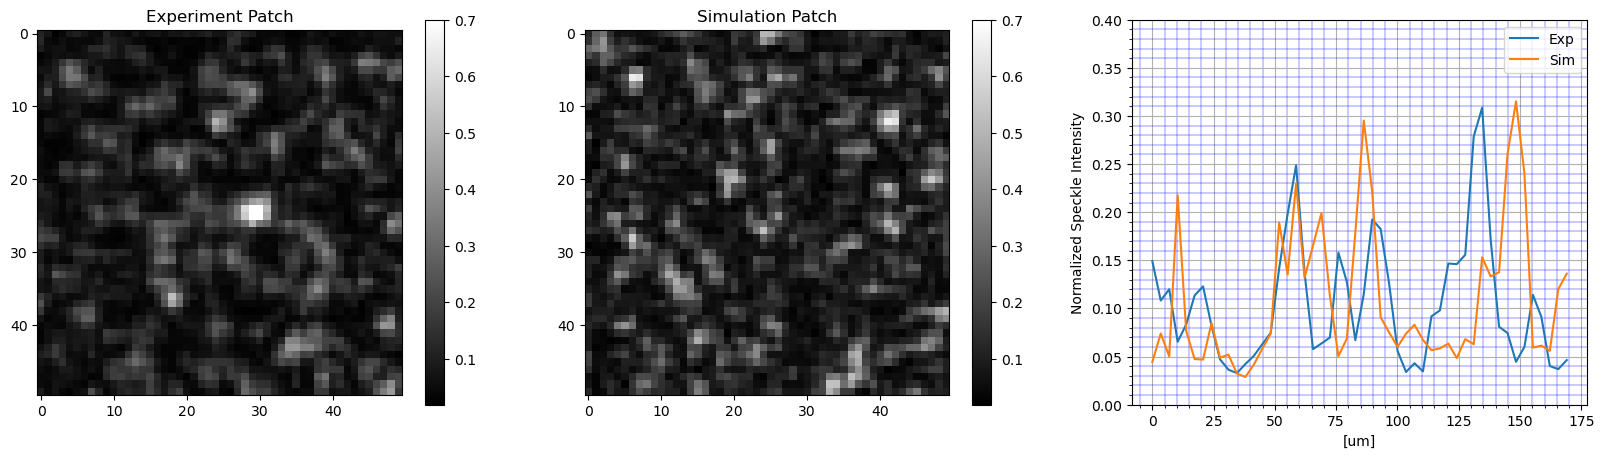

In [30]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

cm0 = axs[0].imshow(ref_img[350:400, 200:250], cmap='gray', vmax=0.7)
plt.colorbar(cm0, ax=axs[0])
axs[0].set_title('Experiment Patch')

rand_shift = int(np.random.normal(scale=5, size=1))
cm1 = axs[1].imshow(output_field_intensity_spat[350+rand_shift:400+rand_shift, 200+rand_shift:250+rand_shift], cmap='gray', vmax=0.7)
plt.colorbar(cm1, ax=axs[1])
axs[1].set_title('Simulation Patch')

axs[2].plot(np.arange(50)*3.45, ref_img[380+int(np.random.normal(scale=5, size=1)), 200:250], label='Exp')
axs[2].plot(np.arange(50)*3.45, output_field_intensity_spat[380+rand_shift, 200:250], label='Sim')

axs[2].minorticks_on()
axs[2].grid(visible=True, which='minor', color='b', linewidth=0.3)
axs[2].grid(visible=True, which='major')
axs[2].legend()

axs[2].set_ylim(0, 0.4)

axs[2].set_xlabel('[um]')
axs[2].set_ylabel('Normalized Speckle Intensity')

plt.show()